# Land cover classification at the Mississppi Delta

In this notebook, you will use a k-means **unsupervised** clustering
algorithm to group pixels by similar spectral signatures. **k-means** is
an **exploratory** method for finding patterns in data. Because it is
unsupervised, you don’t need any training data for the model. You also
can’t measure how well it “performs” because the clusters will not
correspond to any particular land cover class. However, we expect at
least some of the clusters to be identifiable as different types of land
cover.

You will use the [harmonized Sentinel/Landsat multispectral
dataset](https://lpdaac.usgs.gov/documents/1698/HLS_User_Guide_V2.pdf).
You can access the data with an [Earthdata
account](https://www.earthdata.nasa.gov/learn/get-started) and the
[`earthaccess` library from
NSIDC](https://github.com/nsidc/earthaccess):

## STEP 1: Set up

### Step 1a: Load libraries and set GDAL parameters

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><ol type="1">
<li>Import all libraries you will need for this analysis</li>
<li>Configure GDAL parameters to help avoid connection errors:
<code>python      os.environ["GDAL_HTTP_MAX_RETRY"] = "5"      os.environ["GDAL_HTTP_RETRY_DELAY"] = "1"</code></li>
</ol></div></div>

In [ ]:
### reproducible file paths
import os

### serializing and unserializing objects
import pickle

### regular expressions
import re

### warnings control
import warnings

### projecting and mapping
import cartopy.crs as ccrs

### access satellite data
import earthaccess

### spatial data management
import earthpy as et

### vector and shapefile 
import geopandas as gpd

### visualizations
import geoviews as gv

### visualization 
import hvplot.pandas
import hvplot.xarray

### arrays
import numpy as np

### tables
import pandas as pd

### rasters
import rioxarray as rxr
import rioxarray.merge as rxrmerge
import xarray as xr

### progress bars
from tqdm.notebook import tqdm

### polygons
from shapely.geometry import Polygon

### kmeans clustering
from sklearn.cluster import KMeans

### set GDAL parameters
os.environ["GDAL_HTTP_MAX_RETRY"] = "5"
os.environ["GDAL_HTTP_RETRY_DELAY"] = "1"

### don't show non-critical warnings
warnings.simplefilter('ignore')


### Step 1b: Run the caching decorator

Below you can find code for a caching **decorator** which you can use in
your code. To use the decorator:

``` python
@cached(key, override)
def do_something(*args, **kwargs):
    ...
    return item_to_cache
```

This decorator will **pickle** the results of running the
`do_something()` function, and only run the code if the results don’t
already exist. To override the caching, for example temporarily after
making changes to your code, set `override=True`. Note that to use the
caching decorator, you must write your own function to perform each
task!

You might notice that typically in these assignments, we start by creating a data_dir to store our data files. Here, our caching decorator is making the data directory for us.

In [10]:
def cached_matanuska_watershed(func_key, override=False):
    """
    A decorator to cache function results for the
    Matanuska River Watershed dataset (20260212)

    Parameters
    ==========
    func_key : str
        File basename used to save pickled results
    override : bool
        When True, re-compute even if results are already stored
    """

    def compute_and_cache_decorator(compute_function):
        """
        Wrap the caching function

        Parameters
        ==========
        compute_function : function
            The function to run and cache results
        """

        def compute_and_cache(*args, **kwargs):
            """
            Perform computation and cache result, or load cached version.
            """

            # Optional custom cache key for specific calls
            if 'cache_key' in kwargs:
                key = f"{func_key}_{kwargs['cache_key']}"
            else:
                key = func_key

            # Define project-specific path
            path = os.path.join(
                os.getcwd(),
                'matanuska_watershed_20260212',
                'jars',
                f'{key}.pickle'
            )

            # Compute and cache if needed
            if not os.path.exists(path) or override:

                # Ensure directory exists
                os.makedirs(os.path.dirname(path), exist_ok=True)

                # Run computation
                result = compute_function(*args, **kwargs)

                # Save result
                with open(path, 'wb') as file:
                    pickle.dump(result, file)

            else:
                # Load cached result
                with open(path, 'rb') as file:
                    result = pickle.load(file)

            return result

        return compute_and_cache

    return compute_and_cache_decorator


In [11]:
### dataset name
DATASET_NAME = "WBD_19_HU8"

In [12]:
### download, unzip, and set the path to the Matanuska watershed
("matanuska_watershed_gdf")

def read_matanuska_watershed(dataset_name, cache_key=None):
    """
    Download and read the USGS Watershed Boundary Dataset (WBD)
    for the Matanuska River Watershed (HUC8: 19020402)
    """
    
    # 1. Define URL for Alaska WBD (Region 19)
    wbd_url = (
        "https://prd-tnm.s3.amazonaws.com/StagedProducts/Hydrography/WBD/HU8/Shape/"
        f"{dataset_name}.zip"
    )

    
    # 2. Download and unzip dataset
    wbd_dir = et.data.get_data(url=wbd_url)

    
    # 3. Define shapefile path
    wbd_path = os.path.join(
        wbd_dir,
        f"{dataset_name}.shp"
    )

    # 4. Read shapefile
    wbd_gdf = gpd.read_file(
        wbd_path,
        engine="pyogrio"
    )

    # Filter to Matanuska HUC8
    matanuska_gdf = wbd_gdf[wbd_gdf["HUC8"] == "19020402"]

    return matanuska_gdf


## STEP 2: Study site

For this analysis, you will use a watershed from the [Water Boundary
Dataset](https://www.usgs.gov/national-hydrography/access-national-hydrography-products),
HU12 watersheds (WBDHU12.shp).

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><ol type="1">
<li>Download the Water Boundary Dataset for region 8 (Mississippi)</li>
<li>Select watershed 080902030506</li>
<li>Generate a site map of the watershed</li>
</ol>
<p>Try to use the <strong>caching decorator</strong></p></div></div>

We chose this watershed because it covers parts of New Orleans an is
near the Mississippi Delta. Deltas are boundary areas between the land
and the ocean, and as a result tend to contain a rich variety of
different land cover and land use types.

In [13]:
### create directory for caching if it doesn't exist
def read_alaska_state_file(filename, cache_key=None):
    data_path = Path(__file__).resolve().parent.parent / "data" / "raw" / filename
    
    # Example read (replace with your actual logic)
    with open(data_path, "r") as f:
        data = f.read()
    
    return data

In [14]:
gdf = gpd.read_file("GOVTUNIT_Alaska_State_Shape.shp")
print(gdf.head())

gdf.plot()

DataSourceError: GOVTUNIT_Alaska_State_Shape.shp: No such file or directory

In [1]:
wbd_gdf = read_GOVTUNIT_Alaska_State_Shape(
    "GOVTUNIT_Alaska_State_Shape.xml",
    cache_key="GOVTUNIT_Alaska_State_Shape.xml"
)

NameError: name 'read_GOVTUNIT_Alaska_State_Shape' is not defined

In [233]:
wbd_gdf

,tnmid,metasource,sourcedata,sourceorig,sourcefeat,loaddate,referenceg,areaacres,areasqkm,states,...,name,hutype,humod,tohuc,noncontrib,noncontr_1,shape_Leng,shape_Area,ObjectID,geometry
0,{8AFB1AF9-7296-4303-89DE-14CD073B859A},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,"535297,540579",29441.81,119.15,LA,...,Gourd Bayou-Youngs Bayou,S,"LE,ID,DD",080500011308,0.0,0.0,NaN,NaN,1,"POLYGON ((-92.00021 32.53586, -91.99994 32.535..."
1,{916A17A6-B4A0-4FD7-9BB8-FFD1936B15B2},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,535512,11406.67,46.16,LA,...,Hams Creek,S,ID,080802050104,0.0,0.0,NaN,NaN,2,"POLYGON ((-93.37574 30.58982, -93.3747 30.5891..."
2,{493C7EC1-2F1C-4B84-AFFB-6F6868A9868E},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,"547190,559640",29138.21,117.92,LA,...,Caney Creek-Bayou D'Arbonne,S,NM,080402060503,0.0,0.0,NaN,NaN,3,"POLYGON ((-93.07761 32.88752, -93.07784 32.887..."
3,{49A3C087-B460-4F97-9D99-78CBB675248B},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,"77417,78285",17759.39,71.87,AR,...,L'Aigle Creek-Saline River,S,NM,080402020206,0.0,0.0,NaN,NaN,4,"POLYGON ((-92.08947 33.29383, -92.0897 33.2938..."
4,{0FB41498-11EA-4AB1-AF05-E2A8E5E2E274},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,1628466,98564.62,398.88,LA,...,West Cote Blanche Bay,W,NM,080801030800,0.0,0.0,NaN,NaN,5,"POLYGON ((-91.62408 29.73947, -91.62195 29.737..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2636,{9E524E78-2605-48CB-A41F-618AFCDF513D},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,"695171,692611",9132.46,36.96,MS,...,Widow Bayou-Big Sunflower River,S,"AW,LE,TF",080302071707,0.0,0.0,NaN,NaN,2637,"POLYGON ((-90.76273 32.97428, -90.76209 32.973..."
2637,{C11913D9-C534-4755-884C-4CAD470ED143},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,"77280,81842",20587.50,83.31,AR,...,Lindermans Lake-Bayou Des Arc,S,LE,080203010306,0.0,0.0,NaN,NaN,2638,"POLYGON ((-91.73427 34.99197, -91.7342 34.9923..."
2638,{3EEBF422-01AC-4322-A63C-24C0A34E1E4F},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,714675,21405.46,86.62,MO,...,Brewer Lake,S,"LE,DD,IT,TF",080103000102,0.0,0.0,NaN,NaN,2639,"POLYGON ((-89.13715 36.97285, -89.13387 36.970..."
2639,{4734715C-0F4A-4211-BBAE-86605B20B79A},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,"547104,553857",38848.09,157.21,LA,...,Blounts Creek-Calcasieu River,S,ID,080802030302,0.0,0.0,NaN,NaN,2640,"POLYGON ((-92.75965 31.12593, -92.75881 31.125..."


In [234]:
### filter the shapefile to the specific watershed we're using

### define the gdf for the watershed by subsetting the gdf of the whole watershed dataset
delta_gdf = wbd_gdf[wbd_gdf[


    ### filter the gdf to the row(s) with the watershed we want
    ### use "dissolve" to merge the geometries of all the rows matching the target watershed
    f'huc{HUC_LEVEL}'].isin(['080902030506'])].dissolve() 

### check it out
delta_gdf

,geometry,tnmid,metasource,sourcedata,sourceorig,sourcefeat,loaddate,referenceg,areaacres,areasqkm,...,huc12,name,hutype,humod,tohuc,noncontrib,noncontr_1,shape_Leng,shape_Area,ObjectID
0,"POLYGON ((-89.97047 29.74687, -89.96593 29.750...",{E942B72E-599E-48F5-908A-EA5265701C14},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-15,"536881,539539",37355.86,151.17,...,080902030506,Manuel Canal-Spanish Lake,D,GC,080902030508,0.0,0.0,NaN,NaN,2560


In [33]:
import geopandas as gpd
from urllib.parse import urlencode

# ---- your watershed ----
HUC12 = "190204020709"   # <- replace with your 12-digit code

# USGS Watershed Boundary Dataset (HUC12 layer)
base_url = "https://hydro.nationalmap.gov/arcgis/rest/services/wbd/MapServer/6/query"

params = {
    "where": f"huc12='{HUC12}'",
    "outFields": "*",
    "returnGeometry": "true",
    "f": "geojson"
}

# build properly encoded url
query_url = f"{base_url}?{urlencode(params)}"
print(query_url)

# read directly into GeoPandas
AKA_gdf = gpd.read_file(query_url)

print(AKA_gdf.head())
print("CRS:", AKA_gdf.crs)

# save shapefile
AKA_gdf.to_file(f"WBD_HUC12_{HUC12}.shp")

https://hydro.nationalmap.gov/arcgis/rest/services/wbd/MapServer/6/query?where=huc12%3D%27190204020709%27&outFields=%2A&returnGeometry=true&f=geojson
   objectid                                   tnmid  \
0     36849  {09B6994C-0713-4B94-8B03-A460CCF3794E}   

                             metasourceid                    sourcedatadesc  \
0  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   

                                    sourceoriginator sourcefeatureid  \
0  Natural Resources and Conservation Service and...            None   

        loaddate referencegnis_ids  areaacres  areasqkm  ...  \
0  1723704945000           1406051   37773.13    152.86  ...   

                     name hutype humod         tohuc noncontributingareaacres  \
0  Outlet Matanuska River      M    AW  190204010808                        0   

  noncontributingareasqkm                                globalid  \
0                       0  {EF176294-EFD4-49BC-B7B3-B58773C61CCE}   

    

In [34]:
AKA_gdf

,objectid,tnmid,metasourceid,sourcedatadesc,sourceoriginator,sourcefeatureid,loaddate,referencegnis_ids,areaacres,areasqkm,...,name,hutype,humod,tohuc,noncontributingareaacres,noncontributingareasqkm,globalid,shape_Length,shape_Area,geometry
0,36849,{09B6994C-0713-4B94-8B03-A460CCF3794E},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,1723704945000,1406051,37773.13,152.86,...,Outlet Matanuska River,M,AW,190204010808,0,0,{EF176294-EFD4-49BC-B7B3-B58773C61CCE},211082.001708,6.725478e+08,"POLYGON ((-149.06696 61.67939, -149.06707 61.6..."


In [35]:
import holoviews as hv

<Axes: >

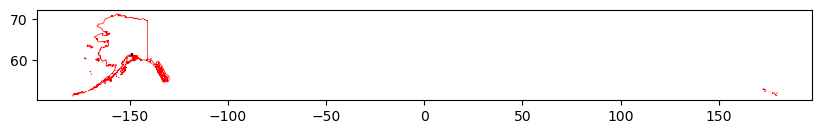

In [37]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 10))
AKA_gdf.plot(ax=ax, facecolor="lightblue", edgecolor="black", linewidth=1)
AKA.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=0.5)


In [38]:
import geopandas as gpd
import zipfile
import requests
import os

# Census state boundary shapefile (500k cartographic boundary)
url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_state_500k.zip"

zip_path = "states.zip"
extract_path = "states"

# download
r = requests.get(url)
with open(zip_path, "wb") as f:
    f.write(r.content)

# unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# read shapefile
states = gpd.read_file(f"{extract_path}/cb_2023_us_state_500k.shp")

# filter to AKA (STATEFP = 19)
AKA = states[states["STATEFP"] == "02"]

AKA.head()

,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
18,02,01785533,0400000US02,02,AK,Alaska,00,1479016910296,245347100126,"MULTIPOLYGON (((-131.61758 54.94795, -131.6107..."


In [39]:
states

,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,35,00897535,0400000US35,35,NM,New Mexico,00,314198587197,726463919,"POLYGON ((-109.05017 31.48, -109.04984 31.4995..."
1,46,01785534,0400000US46,46,SD,South Dakota,00,196341525171,3387709166,"POLYGON ((-104.05788 44.9976, -104.05078 44.99..."
2,06,01779778,0400000US06,06,CA,California,00,403673296401,20291770234,"MULTIPOLYGON (((-118.60442 33.47855, -118.5987..."
3,21,01779786,0400000US21,21,KY,Kentucky,00,102266598312,2384223544,"MULTIPOLYGON (((-89.40565 36.52816, -89.39868 ..."
4,01,01779775,0400000US01,01,AL,Alabama,00,131185049346,4582326383,"MULTIPOLYGON (((-88.05338 30.50699, -88.05109 ..."
5,13,01705317,0400000US13,13,GA,Georgia,00,149485311347,4419673221,"MULTIPOLYGON (((-81.27939 31.30792, -81.27716 ..."
6,05,00068085,0400000US05,05,AR,Arkansas,00,134660466558,3122251184,"POLYGON ((-94.61792 36.49941, -94.61765 36.499..."
7,42,01779798,0400000US42,42,PA,Pennsylvania,00,115881839569,3397855215,"POLYGON ((-80.51989 40.90666, -80.51963 40.911..."
8,29,01779791,0400000US29,29,MO,Missouri,00,178052260322,2487519141,"POLYGON ((-95.77355 40.5782, -95.76853 40.5833..."
9,08,01779779,0400000US08,08,CO,Colorado,00,268418756810,1185758065,"POLYGON ((-109.06025 38.59933, -109.05954 38.7..."


In [40]:
### Make a site map with satellite imagery in the background
AKA_map = AKA_gdf.hvplot(
    # Givethe map a descriptive title
    title="Manauska River Watershed Boundary",
    # Add a basemap
    geo=True, tiles='EsriImagery',
    # Change the colors
    fill_color='white', fill_alpha=0.2,
    line_color='skyblue', line_width=5,
    # Change the image size
    frame_width=400, frame_height=400)

# Save the map as a file to put on the web (OPTIONAL)
hv.save(AKA_map, "AKA_map.html")

# Display the map
AKA_map



:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-response"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div></div><div class="callout-body-container callout-body"><p>Write a 2-3 sentence <strong>site description</strong> (with
citations) of this area that helps to put your analysis in context.</p></div></div>


**YOUR SITE DESCRIPTION HERE**

## STEP 3: Multispectral data

### Step 3a: Search for data

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><ol type="1">
<li>Log in to the <code>earthaccess</code> service using your Earthdata
credentials:
<code>python      earthaccess.login(persist=True)</code></li>
<li>Modify the following sample code to search for granules of the
HLSL30 product overlapping the watershed boundary from May to October
2023 (there should be 76 granules):
<code>python      results = earthaccess.search_data(          short_name="...",          cloud_hosted=True,          bounding_box=tuple(gdf.total_bounds),          temporal=("...", "..."),      )</code></li>
</ol></div></div>

In [236]:
### Log in to earthaccess
earthaccess.login(persist = True)


In [237]:
### Search for HLS granules we want
results = earthaccess.search_data(


    ### specify which dataset and spatial resolution we want 
    short_name = 'HLSL30',


    ### specify that we're using cloud data
    cloud_hosted = True,

    ### use the bounding box from our watershed boundary
    bounding_box = tuple(delta_gdf.total_bounds),


    ### set the temporal range of the data
    temporal = ("2024-06", "2028-08")

)

In [238]:
print(results)


[Collection: {'EntryTitle': 'HLS Landsat Operational Land Imager Surface Reflectance and TOA Brightness Daily Global 30m v2.0'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -89.79864173, 'Latitude': 29.70347853}, {'Longitude': -89.76643746, 'Latitude': 30.69278312}, {'Longitude': -90.91181412, 'Latitude': 30.71627038}, {'Longitude': -90.93262544, 'Latitude': 29.72659663}, {'Longitude': -89.79864173, 'Latitude': 29.70347853}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2024-06-07T16:31:11.509Z', 'EndingDateTime': '2024-06-07T16:31:11.509Z'}}
Size(MB): 169.50417041778564
Data: ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T15RYP.2024159T163111.v2.0/HLS.L30.T15RYP.2024159T163111.v2.0.B10.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T15RYP.2024159T163111.v2.0/HLS.L30.T15RYP.2024159T163111.v2.0.SAA.tif', 'https://data.lpdaa

### Step 3b: Compile information about each granule

I recommend building a GeoDataFrame, as this will allow you to plot the
granules you are downloading and make sure they line up with your
shapefile. You could also use a DataFrame, dictionary, or a custom
object to store this information.

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><ol type="1">
<li>For each search result:
<ol type="1">
<li>Get the following information (HINT: look at the [‘umm’] values for
each search result):
<ul>
<li>granule id (UR)</li>
<li>datetime</li>
<li>geometry (HINT: check out the shapely.geometry.Polygon class to
convert points to a Polygon)</li>
</ul></li>
<li>Open the granule files. I recommend opening one granule at a time,
e.g. with (<code>earthaccess.open([result]</code>).</li>
<li>For each file (band), get the following information:
<ul>
<li>file handler returned from <code>earthaccess.open()</code></li>
<li>tile id</li>
<li>band number</li>
</ul></li>
</ol></li>
<li>Compile all the information you collected into a GeoDataFrame</li>
</ol></div></div>

In [239]:
### make a function to process all the granules from the earthaccess search
### and extract information for each granule

### define the function
def get_earthaccess_links(url_pattern):

    ### make and display a progress bar
    #f = IntProgress(min = 0, max = len(url_pattern), description = 'Open granules')
    #display(f)

    ### use a regular expression to extract tile_id and bank from .tif files
    url_pattern = re.compile(
        r'\.(?P<tile_id>\w+)\.\d+T\d+\.v\d\.\d\.(?P<band>[A-Za-z0-9]+)\.tif')


    ### accumulate gdf rows from each granule
    link_rows = []

    ### loop over granules to extract info
    for granule in url_pattern:

        ### locate metadata (UMM = universal metadata model)
        umm = granule["umm"]
        granule_id = umm["GranuleUR"]

        ### extract date/time
        #datetime = pd.to_datetime(
         #   umm['TemporalExtent']['RangeDateTime']['BeginningDateTime'])

        temporal = umm["TemporalExtent"]["RangeDateTime"]
        start_time = temporal["BeginningDateTime"]
        end_time = temporal["EndingDateTime"]
        

        ### extract coordinate points for the granule
        points = (
            umm["SpatialExtent"]
            ["HorizontalSpatialDomain"]
            ["Geometry"]
            ["GPolygons"][0]
            ["Boundary"]
        )
      

        ### make polygon using coordinate points for granule
        geometry = Polygon(
            [(point['Longitude'],
              point['Latitude']) for point in points]
        )


        ### get url and open granule
        files = earthaccess.open([granule])

        ### loop through each file in the granule
        for file in files:


            ### use url regular expression to get url
            match = url_re.search(file.full_name)
            

            ### if match is found, append data to link_rows gdf we initialized
            if match is not None:
                link_rows.append(

                    ### makes a gdf with the granule's data and geometry
                    gpd.GeoDataFrame(
                        dict(

                            ### timestamp
                            datetime = [datetime],

                            ### unique id
                            tile_id = [match.group('tile_id')],

                            ### band name
                            band = [match.group('band')],

                            ### url
                            url = [file],

                            ### polygon
                            geometry = [geometry]
                        ),

                        ### set crs
                        crs = "EPSG:4326"

                    )
                )

        ### update progress bar after each granule is done
        f.value += 1

    ### combine into a single gdf
    file_df = pd.concat(link_rows).reset_index(drop = True)

    ### return the final gdf file
    return file_df


In [241]:
#url_pattern = re.compile(
 #       r'\.(?P<tile_id>\w+)\.\d+T\d+\.v\d\.\d\.(?P<band>[A-Za-z0-9]+)\.tif')

In [242]:
granule = results[0]
granule


Collection: {'EntryTitle': 'HLS Landsat Operational Land Imager Surface Reflectance and TOA Brightness Daily Global 30m v2.0'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -89.79864173, 'Latitude': 29.70347853}, {'Longitude': -89.76643746, 'Latitude': 30.69278312}, {'Longitude': -90.91181412, 'Latitude': 30.71627038}, {'Longitude': -90.93262544, 'Latitude': 29.72659663}, {'Longitude': -89.79864173, 'Latitude': 29.70347853}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2024-06-07T16:31:11.509Z', 'EndingDateTime': '2024-06-07T16:31:11.509Z'}}
Size(MB): 169.50417041778564
Data: ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T15RYP.2024159T163111.v2.0/HLS.L30.T15RYP.2024159T163111.v2.0.B10.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T15RYP.2024159T163111.v2.0/HLS.L30.T15RYP.2024159T163111.v2.0.SAA.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T15RYP.2024159T163111.v2.0/HLS.L30.T15RYP.2024159T163111.v2.0.VZA.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T15RYP.2024159T163111.v2.0/HLS.L30.T15RYP.2024159T163111.v2.0.B06.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T15RYP.2024159T163111.v2.0/HLS.L30.T15RYP.2024159T163111.v2.0.B09.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T15RYP.2024159T163111.v2.0/HLS.L30.T15RYP.2024159T163111.v2.0.B04.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T15RYP.2024159T163111.v2.0/HLS.L30.T15RYP.2024159T163111.v2.0.B03.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T15RYP.2024159T163111.v2.0/HLS.L30.T15RYP.2024159T163111.v2.0.B07.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T15RYP.2024159T163111.v2.0/HLS.L30.T15RYP.2024159T163111.v2.0.VAA.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T15RYP.2024159T163111.v2.0/HLS.L30.T15RYP.2024159T163111.v2.0.Fmask.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T15RYP.2024159T163111.v2.0/HLS.L30.T15RYP.2024159T163111.v2.0.B01.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T15RYP.2024159T163111.v2.0/HLS.L30.T15RYP.2024159T163111.v2.0.SZA.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T15RYP.2024159T163111.v2.0/HLS.L30.T15RYP.2024159T163111.v2.0.B11.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T15RYP.2024159T163111.v2.0/HLS.L30.T15RYP.2024159T163111.v2.0.B05.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSL30.020/HLS.L30.T15RYP.2024159T163111.v2.0/HLS.L30.T15RYP.2024159T163111.v2.0.B02.tif']

In [243]:
info_dict = granule['umm']
info_dict

{'TemporalExtent': {'RangeDateTime': {'BeginningDateTime': '2024-06-07T16:31:11.509Z',
   'EndingDateTime': '2024-06-07T16:31:11.509Z'}},
 'GranuleUR': 'HLS.L30.T15RYP.2024159T163111.v2.0',
 'AdditionalAttributes': [{'Name': 'LANDSAT_PRODUCT_ID',
   'Values': ['LC08_L1TP_022039_20240607_20240607_02_RT']},
  {'Name': 'CLOUD_COVERAGE', 'Values': ['10']},
  {'Name': 'MGRS_TILE_ID', 'Values': ['15RYP']},
  {'Name': 'SPATIAL_COVERAGE', 'Values': ['100']},
  {'Name': 'SPATIAL_RESOLUTION', 'Values': ['30.0']},
  {'Name': 'SPATIAL_RESAMPLING_ALG', 'Values': ['Cubic Convolution']},
  {'Name': 'HLS_PROCESSING_TIME', 'Values': ['2024-06-21T18:26:46Z']},
  {'Name': 'SENSING_TIME', 'Values': ['2024-06-07T16:31:11.5093050Z']},
  {'Name': 'HORIZONTAL_CS_NAME', 'Values': ['UTM, WGS84, UTM ZONE 15']},
  {'Name': 'ULX', 'Values': ['699960.0']},
  {'Name': 'ULY', 'Values': ['3400020.0']},
  {'Name': 'ADD_OFFSET', 'Values': ['0']},
  {'Name': 'REF_SCALE_FACTOR', 'Values': ['0.0001']},
  {'Name': 'THERM_SC

In [244]:
### run the function to get granule search url_pattern
file_df = get_earthaccess_links(url_pattern)

TypeError: 're.Pattern' object is not iterable

### Step 3c: Open, crop, and mask data

This will be the most resource-intensive step. I recommend caching your
results using the `cached` decorator or by writing your own caching
code. I also recommend testing this step with one or two dates before
running the full computation.

This code should include at least one **function** including a
numpy-style docstring. A good place to start would be a function for
opening a single masked raster, applying the appropriate scale
parameter, and cropping.

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><ol type="1">
<li>For each granule:
<ol type="1">
<li><p>Open the Fmask band, crop, and compute a quality mask for the
granule. You can use the following code as a starting point, making sure
that <code>mask_bits</code> contains the quality bits you want to
consider: ```python # Expand into a new dimension of binary bits bits =
( np.unpackbits(da.astype(np.uint8), bitorder=‘little’)
.reshape(da.shape + (-1,)) )</p>
<p># Select the required bits and check if any are flagged mask =
np.prod(bits[…, mask_bits]==0, axis=-1) ```</p></li>
<li><p>For each band that starts with ‘B’:</p>
<ol type="1">
<li>Open the band, crop, and apply the scale factor</li>
<li>Name the DataArray after the band using the <code>.name</code>
attribute</li>
<li>Apply the cloud mask using the <code>.where()</code> method</li>
<li>Store the DataArray in your data structure (e.g. adding a
GeoDataFrame column with the DataArray in it. Note that you will need to
remove the rows for unused bands)</li>
</ol></li>
</ol></li>
</ol></div></div>

In [ ]:
### apply cached decorator to function
@cached('delta_reflectance_da_df')



### write function that computes reflectance data using 
### search results (df of urls) and watershed boundary
def compute_reflectance_da(url_pattern, boundary_gdf):

"""
Connect to files using VIS, crop them, apply a cloud mask, and wrangle

Return a signle reflectance DataArray with bands as columns
and centroid coordinates and datetime as the index

Parameters
==========
search_results: list
    search results links to the files (urls)
boundary_gdf: gpd.GeoDataFrame
    Boundary used to crop the data
""""


### write a function to open raster from url, apply scale factor, crop, and mask data
def open_dataarray(url, boundary_proj_gdf, scale = 1, masked = True):

    ### open raster data
    da = rxr.open_rasterio(url, masked = masked).squeeze() * scale

    ### reproject the boundary to match the raster data
    if boundary_proj_gdf is None:
        boundary_proj_gdf = boundary_gdf.to_crs(da.rio.crs)

    ### crop raster to bounding box
    cropped = da.rio.clip_box(*boundary_proj_gdf.total_bounds)

    return cropped

    ### write function to apply a cloud mask
    def compute_quality_mask(da, mask_bits = [1, 2, 3]):

        """Mask out quality data by bit"""

        ### unpack the bits to new axis
        bits = (

            ###unpack each number into individual bits 
            np.unpackbits(

                ###convert to 8-bit unsigned integer format
                da.astype(np.uint6),

                ### set the order of the bits
                bitorder = 'little'

            ### reshape to the match original data with an exttra dimension for the bits
            ).reshape(da.shape + (-1,))
            )
        
        ### grab the bits we want and chack if thier flagged 
        mask = np.prod(

            ### open bits
            bits[
                ...,
                            mask_bits] == 0,
                            axis = -1)
            
        ### return the mask
        return mask

    ### grab metadata
    file_df = get_earthaccess_links(url_pattern)

    ### store results for each granule
    granule_da_rows = []

    ### store projected boundary
    boundary_proj_gdf = None

    ### group the data by each granule 
    group_iter = file_df.groupby(

        ### datetime and tile_id
        ['datetime', 'tile_id'])

    ### loop through each image and its metadata
    for (datetime, tile_id), granule_df in tqdm(group_iter)

        ### print status bar
        print(f'Processing granule {tile_id} from {datetime}')

        ### find each granule's cloud cover file (fmask) url
        cloud_mask_url = (
            granule_df[granule_df.band == 'Fmask', 'url']
        ) 
    
        ###open granule cloud cover
        cloud_mask_cropped = open_dataarray(cloud_mask_url, boundary_proj_gdf, masked = False)

        ### compute cloud mask
        cloud_mask = compute_quality_mask(cloud_mask_cropped_da)

        ### loop through each spectral band to open, crop, and mask the band
        da_list = []
        da_list = []

        ### loop through each band in the granule
        for i, row in granule_df.iterrows():

            ### only open spectral bands (not cloud mask)
            if row.band.startswith('B'):

                ### open bands raster and scale to reflectance
                band_cropped = open_dataarray(
                    row.url, boundary_proj_gdf, scale = 0.0001
                )

                ### name the raster by the band
                band_cropped.name = row.band

                ### apply the cloud mask to the raster
                row['da'] = band_cropped.where(cloud_mask)

            ### append the row to granule_da_rows
            granule_da_rows.append(row)

    ### reassemble the metadata df
    return pd.concat(granule_da_rows)



SyntaxError: incomplete input (318473355.py, line 55)

One main reason this code is wrong is that parts of it wouldn’t actually run because of how it’s structured. For example, the compute_quality_mask function is written after a return statement and indented inside another function, which means Python will never reach it or properly define it. There are also small syntax mistakes—like using np.uint6 (which isn’t a real data type), a missing colon in a for loop, and inconsistent variable names—that would cause immediate errors. Some variables are referenced before they’re created, and a few lines of DataFrame indexing aren’t written correctly. In simple terms, the logic of the workflow makes sense, but the code has structural and syntax issues that would stop it from running successfully without fixing those problems first.

I think keeping track of my variables is somthing to imporove on. making sure im not calling one variabel multiple things.

In [248]:
### apply the function
reflectance_da_df = compute_reflectance_da(url_pattern, delta_gdf)


NameError: name 'compute_reflectance_da' is not defined

In [247]:
### check out the dataframe
reflectance_da_df


NameError: name 'reflectance_da_df' is not defined

### Step 3d: Merge and Composite Data

You will notice for this watershed that:   
1. The raster data for each date are spread across 4 granules  
2. Any given image is incomplete because of clouds

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><ol type="1">

*   1. For each band:  
    *   a. For each date:  
        *   i. Merge all 4 granules  
        *   ii. Mask any negative values created by interpolating from the nodata value of -9999 (`rioxarray`) should account for this, but doesn't appear to when merging. If you leave these values in, they will create problems later on
    *   b. Concatenate the merged DataArrays along a new date dimension  
    *   c. Take the mean in the date dimension to create a composite image that fills cloud gaps  
    *   d. Add the band as a dimensions, and give the DataArray a name  
*   2. Concatenate along the band dimension


In [ ]:
### apply cache decorator
@cached('delta_reflectance_da')

### create a function to merge and composite reflectance data from multiple granules
### end result: single, composite reflectance image for each spectral band
def merge_and_composite_arrays(granule_da_df):

    ### initialize a list to store dfs
    da_list = []

    ### initialize a list to store composites after procesing
    for band, band_df in granule_da_df.groupby('band'):

        ### list for date/time of image acquisition
        merged_das = []

        ### loop over date/time of image acquisition and merge granules for each data
        for datetime, granule_df in band_df.groupby('datetime'):

            ### merge granles for each date
            merged_da = rxrmerge.merge_arrays(list(date_df.da))
                

           
            ### mask negative values (could be no data or invalid data)
            merged_da = merged_da.where(merged_da >= 0)
            
            

            ### append to merged_das list we initialized
            merged_das.append(merged_da)

            
        ### composite images across dates
        composite_da = xr.concat(merged_das,
                            
                            ### make a datetime dimension
                            ### calculate median value across date time pixels
                            dim = 'datetime').median(dim = 'datetime')


        ### assign the band number to the attribute of composite data array
        compossite_da['band'] = int(band[1:])

        ### add processed and composite data array to list
        da_list.append(composite_da)

    ### concatenates composite data arrays for each band along band dimension
    return xr.concat(da_list, dim='band')



This code walks through a typical remote sensing visualization workflow. It starts by selecting specific spectral bands—4, 3, and 2—from a reflectance dataset to build a true-color RGB image. Next, it uses hvplot.rgb() to display the image, setting the correct spatial proportions and simplifying the view by removing axis labels. After plotting, the reflectance values are scaled from their original range (likely 0–1) to an 8-bit range (0–255), which is standard for image display and processing. Finally, the code overlays k-means clustering results on top of the RGB image by converting the cluster output into an xarray format, sorting it by spatial coordinates, and plotting it with a colorblind-friendly colormap. Overall, the script moves from preparing image bands, to visualizing them, to enhancing display values, and then adding classification results for interpretation.

In [ ]:
### call function to get final composite reflectance data 
reflectance_da = merge_and_composite_arrays(reflectance_da_df)


## STEP 4: K-means clustering

Cluster your data by spectral signature using the k-means algorithm.

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><ol type="1">
<li>Convert your DataArray into a <strong>tidy</strong> DataFrame of
reflectance values (hint: check out the <code>.to_dataframe()</code> and
<code>.unstack()</code> methods)</li>
<li>Filter out all rows with no data (all 0s or any N/A values)</li>
<li>Fit a k-means model. You can experiment with the number of groups to
find what works best.</li>
</ol></div></div>

In [ ]:
### Convert spectral DataArray to a tidy DataFrame
model_df = (reflectance_da
            
            ### flatten the array into a long dataframe
            .to_dataframe()

            ### select the reflectance column
            .reflectance

            ### make the table wide: each row will be a pixel location
            ### and each column is a spectral band with the reflectance  value
            .unstack('band')
            )

model_df

### filter out rows with no data
model_df = model_df.drop(columns = [10, 11]).dropna(
model_df

In [ ]:
min_values = model_df.min()
max_values = model_df.max()

print(min_values)
print(max_values)

Now we're reading to fit the k-means clustering model. We can run the fit and prediction functions at the same time because we don't have target data.

In [ ]:
### initialize k-means model 
k_means = KMeans(n_clusters = 5)

### fit model and predict
predicted = k_means.fit_predict(model_df.values)


### add the predicted values back to the model dataframe
model_df['cluster'] = predicted
model_df

## STEP 5: Plot

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try It</div></div><div class="callout-body-container callout-body"><p>Create a plot that shows the k-means clusters next to an RGB image of
the area. You may need to brighten your RGB image by multiplying it by
10. The code for reshaping and plotting the clusters is provided for you
below, but you will have to create the RGB plot yourself!</p>
<p>So, what is <code>.sortby(['x', 'y'])</code> doing for us? Try the
code without it and find out.</p></div></div>

In [ ]:
### make data array with bands to use for rgb: red, green, and blue
rgb_da = reflectance_da.sel(band = [4, 3, 2])


In [ ]:
### plot rgb
(
    rgb.hvplot.rgb(
        x = 'x',
        bands = 'band',
        data_aspect = 1,
        xaxis = None,
        yaxis = None)

    )



In [ ]:
### stretch values
rgb_unit8 = (rgb * 255).astype(np.unit8).where(rgb != np.nan)
rgb_unit8

In [ ]:
### plot the k-means clusters
(
    rgb_plot
    + 
    model_df.clusters.to_xarray().sortby(['x', 'y']).hvplot(
        cmap="Colorblind", aspect='equal') 
)

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-respond"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Reflect and Respond</div></div><div class="callout-body-container callout-body"><p>Don’t forget to interpret your plot!</p></div></div>

**YOUR PLOT HEADLINE AND DESCRIPTION HERE**

This code shows a clear and thoughtful process for working with satellite imagery. First, you select the red, green, and blue bands to create a true-color image, which is a standard and effective way to visualize the landscape. Using hvplot.rgb() keeps the image properly scaled and clean-looking, especially with the axes removed and the aspect ratio set correctly so the map doesn’t look stretched. You then scale the reflectance values to an 8-bit range (0–255), which makes the image display properly on screen. One small issue is the way NaN values are handled—comparing directly to np.nan won’t work as expected, so that part could be adjusted. Finally, overlaying the k-means clusters on top of the RGB image is a strong step because it connects the visual image to your classification results. Overall, the workflow makes sense, flows logically, and shows a solid understanding of how to process, visualize, and interpret remote sensing data, with just a minor technical fix needed for handling missing values.